# Imports

In [1]:
suppressMessages({
    library(GSVA) #ssgsea, need matrixStats = v1.1
    library(fgsea)
    library(msigdbr)
    library(lmerTest)
    library(dplyr)
    library(stringr)
    library(readxl)
    library(pheatmap) #or ComplexHeatmap?
    library(openxlsx)
    library(ggplot2)
    library(repr)
    library(RColorBrewer)
    library(ggrepel)
    library(multcomp) # glht
    library(data.table) # contains %like%
    library(msigdbr)
    library(forcats)
    library(scales)
    library(ggpubr) #contains stat_compare_means()
    })
# %config IPCompleter.use_jedi = False
task_id <- as.integer(Sys.getenv("SLURM_ARRAY_TASK_ID", "1"))
node <- Sys.getenv("SLURM_JOB_NODELIST","1")
num_workers = as.integer(Sys.getenv("SLURM_CPUS_PER_TASK","4"))
print(paste('Task:',task_id,"on",node,'num_workers',num_workers))
# options(future.globals.maxSize = (256/num_workers)* 1024^3,
#        future.seed=TRUE) 
# plan("multisession", workers = num_workers)  
# plan("default")

prj = "HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq"
base = file.path('/ix/rbao/Projects', prj)
scripts= file.path(base,'scripts')
results = file.path(base,'results','visium')
sampleinfo = file.path(base,'sampleinfo')
data = file.path(base,'data','visium','spaceranger')
issues_marked <- file.path(results,'cloupe_region_exlcusions')
info = read.csv(file.path(sampleinfo,'32_visium_tissue_positions_paths.csv'))
df=  read.table(file.path(sampleinfo,'55_combined_sample_info_062525_bi_32_vis_23_chrom.tsv'),
                header =2,
                sep = '\t')
head(info,n=3)
head(df,n=3)

[1] "Task: 1 on htc-n30 num_workers 1"


,X,Unnamed..0.1,Unnamed..0,sample_name,csv_path,json_path,svs_path,visium_dir,regist_target_img_scalef,tissue_hires_scalef,tissue_lowres_scalef,fiducial_diameter_fullres,spot_diameter_fullres
,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,0,25_0065,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0065_done/25_0065/outs,0.7512208,0.25040692,0.07512207,25.77433,17.18289
2,1,1,1,25_0066,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0066_done/25_0066/outs,0.1960848,0.06536161,0.01960848,104.52780,69.68520
3,2,2,2,25_0067,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs/spatial/tissue_positions.csv,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs/spatial/scalefactors_json.json,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067_vis.svs,/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/data/visium/spaceranger/25_0067_done/25_0067/outs,0.2429346,0.08097822,0.02429347,415.94381,277.29587


,Original.ID,CGF.ID,Pool.ID,Status,Human.WTA.Probes,Smoking.Status,any_tobacco_smoker,current_smoker,response_status,Assay,CGF.Sample.ID,HTGC.Sample.ID,Visium.Slide.Position..A1.or.D1..in.Cytassist,Slide.orientation.in.Cytassist,Estimated...Cover..Cytassist.,Index.name,Index..i7..sequence,Index..a_i5.,Index..b_i5.,group
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,21-091-003,25_0113,Cure_002_pool,Pass,BC002,never,no,no,,chromium,,NA,,,NA,,,,,21-091
2,21-091-004,25_0114,Cure_001_pool,Pass,BC016,"patient CTB 1/21/24 - per EPIC, former smoker 1991-2011",yes,no,,chromium,,NA,,,NA,,,,,21-091
3,21-091-005,25_0115,Cure_002_pool,Pass,BC003,patient CTB 4/9/24 - per EPIC never smoked,no,no,,chromium,,NA,,,NA,,,,,21-091


# Functions

In [73]:
any(lapply(X = save.gs$pathway, FUN = nchar) > 1000)

[1] FALSE

In [2]:
shorten.pathways <- function(pathways,n){
    pathways <- stringr::str_replace_all(pathways, pattern='_',
                                               replacement = ' ')
    new.pathways <- c()
    for (path in pathways){
        if (nchar(path) > n){
            a <-stringr::str_split(path, pattern = "\\.")[[1]]
            d = length(a)
            new.path<- paste(a[d-2],a[d-1],a[d],path,sep='.')
        } else {
            new.path <- path
        }
        new.pathways <- c(new.pathways,new.path)
    }

    new.pathways <- stringr::str_trunc(new.pathways,n)
    return(new.pathways)
    }
strip.first.pathway.string <- function(pathways,n=1000){
    new.pathways <- c()
    for (path in pathways){
        a <-stringr::str_split(path, pattern = "_")[[1]]
        d= length(a)
        new.path <- stringr::str_replace(path,pattern=paste0(a[1],'_'),replacement = '')
        new.pathways <- c(new.pathways,new.path)
    }
    if (any(lapply(X = pathways, FUN = nchar) > n)){
        new.pathways <- stringr::str_trunc(new.pathways,n)
    }
    return(new.pathways)
}
prepare.dat.for.heatmap <- function(save.gs, p.crit=1, row.name.length=50){
    save.gs <- save.gs[save.gs$padj <= p.crit, ] 
    dat <- save.gs %>% arrange(cell.type,contrast) %>%
               tidyr::pivot_wider(id_cols = pathway,
                                  values_from=NES,
                                  names_from=contrast.celltype) %>%               
               as.data.frame() %>%
               filter(if_any(everything(), ~ !is.na(.x)))
    row.names(dat) <- shorten.pathways(dat$pathway,row.name.length)
    dat <- dat %>% arrange(pathway)
    dat$pathway <- NULL
    dat <- as.matrix(dat)
    return(dat)
}
pheatmap.wrapper <- function(lognorm.dat, annotation_col, 
                             ann_colors, title, cluster_rows=TRUE,
                             cluster_cols=TRUE,
                             scale="row"){    
  
   p1<- pheatmap(
      lognorm.dat,
      main = title,
      scale = scale,                 # row-wise z-score normalization
      annotation_col = annotation_col,
      annotation_colors = ann_colors,
      clustering_method = "complete",
      cluster_rows = cluster_rows,
      cluster_cols = cluster_cols,
      color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
      show_colnames = FALSE,
      show_rownames = TRUE
    ) 
    return(p1)
}

save_figs <-function(fn,save.dir,p1,wh){
    dir.create(save.dir,recursive = TRUE) 
    print(sprintf('%s/%s', save.dir,fn))
    width = wh[1]
    height = wh[2]
    pdf(file.path(save.dir,paste0(fn,'.pdf')),
        width =width,
        height = height)
    print(p1)
    dev.off()

    png(file.path(save.dir,paste0(fn,'.png')),
        width = width*100,
        height = height*100 )
    print(p1)
    dev.off()
    }


In [3]:
# de <- read.csv(file.path(results,"DEG_contrasts_wilcox/csv/166897_all_spot_wise_DEG_by_celltpe_and_contrast_1.minpct.v2.csv"),
#               row.names=1)
de <- read.csv(file.path(results,"DEG_contrasts_wilcox_v3/csv/166897_all_spot_wise_DEG_by_celltpe_and_contrast_1.minpct.v3.csv"),
               row.names=1)

print(paste(length(unique(row.names(de))),length(unique(de$Gene))))
head(de)

[1] "166897 17205"


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,Gene,log2FC,p.adj,diffexpressed,delabel,contrast,cell.type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
DLK1,1.227241e-221,3.395384,0.087,0.014,2.219465e-217,DLK1,3.395384,2.219465e-217,UP,DLK1,any_tobacco_smoker.yes.vs.no,fibroblast
COL2A1,4.176081e-79,3.375949,0.027,0.003,7.552443e-75,COL2A1,3.375949,7.552443e-75,UP,COL2A1,any_tobacco_smoker.yes.vs.no,fibroblast
SCUBE1,1.837330e-121,3.351130,0.037,0.003,3.322810e-117,SCUBE1,3.351130,3.322810e-117,UP,SCUBE1,any_tobacco_smoker.yes.vs.no,fibroblast
GATA4,1.228116e-196,2.939434,0.069,0.009,2.221047e-192,GATA4,2.939434,2.221047e-192,UP,GATA4,any_tobacco_smoker.yes.vs.no,fibroblast
ARX,2.784882e-177,2.889631,0.063,0.008,5.036459e-173,ARX,2.889631,5.036459e-173,UP,ARX,any_tobacco_smoker.yes.vs.no,fibroblast
COLEC11,0.000000e+00,2.801831,0.164,0.029,0.000000e+00,COLEC11,2.801831,0.000000e+00,UP,COLEC11,any_tobacco_smoker.yes.vs.no,fibroblast


# Load gene sets

In [4]:
all.hallmark <- msigdbr(species = "Homo sapiens", category = "H") # Hallmark
all.c2 <- msigdbr(species = "Homo sapiens", category = "C2")
# c2.cp <- msigdbr(species = "Homo sapiens", category = "C2", subcategory = "CP") # cannonical 
all.c4 <- msigdbr(species = "Homo sapiens", category = "C4")
# c4.3CA <-
#C5 is GO
all.c5 <- msigdbr(species = "Homo sapiens", category = "C5")
all.c6 <- msigdbr(species = "Homo sapiens", category = "C6") #Oncogenic
all.c7 <-  msigdbr(species = "Homo sapiens", category = "C7") #, subcategory= "ImmuneSigDB") #Immune
# all.gs = rbind(all.hallmark,all.c1,all.c2,all.c7)

In [43]:
# react <- unique(all.c2$gs_name[grepl('REACTOME',all.c2$gs_name)])
# kegg <- unique(all.c2$gs_name[grepl('KEGG',all.c2$gs_name)])
# wikip <- unique(all.c2$gs_name[grepl('WP',all.c2$gs_name)])
# biocarta <- unique(all.c2$gs_name[grepl('BIOCARTA',all.c2$gs_name)])
# all_gs <- c(react,kegg,wikip,biocarta)
# all_gs <- unique(all.gs$gs_name)#, all.c1$gs_name, all.hallmark$gs_name)
broad <- list()
for (gs in all_gs){
    broad[[gs]] <- unlist(all.gs[all.gs$gs_name==gs, 'human_gene_symbol'])
}

In [44]:
length(broad)

[1] 6715

# fgsea

## Hallmark genesets

In [125]:
use.gs <- unique(all.hallmark$gs_name)#, all.c1$gs_name, all.hallmark$gs_name)
hallmark <- list()
for (gs in use.gs){
    hallmark[[gs]] <- unlist(all.hallmark[all.hallmark$gs_name==gs, 'human_gene_symbol'])
}
true_sizes <- vapply(c2, length, integer(1))
print(true_sizes[1:3])


In [126]:
save.gs <- data.frame(c())
cell.types <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','endothelial cell') #'plasmacytoid dendritic cell'
tags <- c('response_status.R.vs.NR','any_tobacco_smoker.yes.vs.no')
for (cell in cell.types){
    for (tag in tags){        
        deg <- de %>% filter(cell.type==cell) %>% 
                      filter(contrast ==tag) %>%
                      arrange(-avg_log2FC)
        if (grepl(pattern='response',tag)){
            resp <- 'responder'
        } else {
            resp <- 'smoker'
        }        
        temp <- as.double(deg$avg_log2FC)
        names(temp)<- deg$Gene #This is a named vector
        fgseaRes <- fgsea(pathways = hallmark, 
                          stats    = temp,
                          minSize  = 15,
                          maxSize  = 500)
        sig.gs <- fgseaRes %>%   
                    # filter(!is.na(log2err)) %>%
                     arrange(padj) #%>%
                     # dplyr::select(-leadingEdge)
        sig.gs$contrast <- resp
        sig.gs$cell.type <- cell
        save.gs <- rbind(save.gs,sig.gs)
    }
}
save.gs$contrast.celltype <- paste(save.gs$contrast,
                                   save.gs$cell.type,
                                   sep='.')
save.gs$contrast <- factor(save.gs$contrast,
                           levels = c( 'smoker','responder'))

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (3.25% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


In [127]:
pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_hallmark_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx',
                          dim(save.gs)[1]))

print(pnfn)
write.xlsx(save.gs,pnfn)

out <- save.gs %>%  dplyr::left_join(
                            tibble::tibble(pathway = names(true_sizes), total_geneset_size = true_sizes),
                            by = "pathway") %>%
                    mutate(top.genes.observed = lengths(leadingEdge)) %>%
                    mutate(proportion.of.geneset = sprintf('%d/%d',top.genes.observed,total_geneset_size)) %>% 
                    arrange(padj,-lengths(leadingEdge)) %>%
                    dplyr::select(-leadingEdge)

pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_hallmark_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv',
                          dim(save.gs)[1]))
print(pnfn)
write.csv(out,pnfn)
save.gs <- out

[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_699_hallmark_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx"
[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_699_hallmark_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv"


## Heatmap

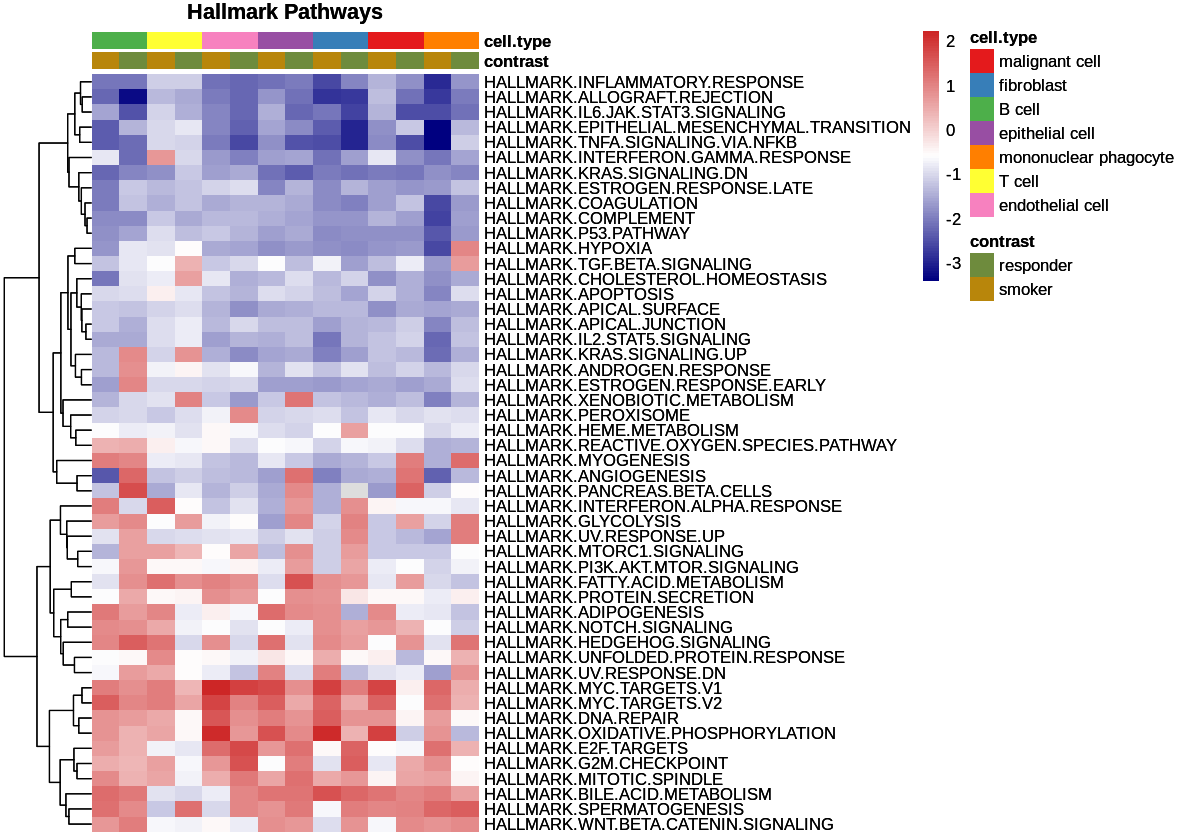

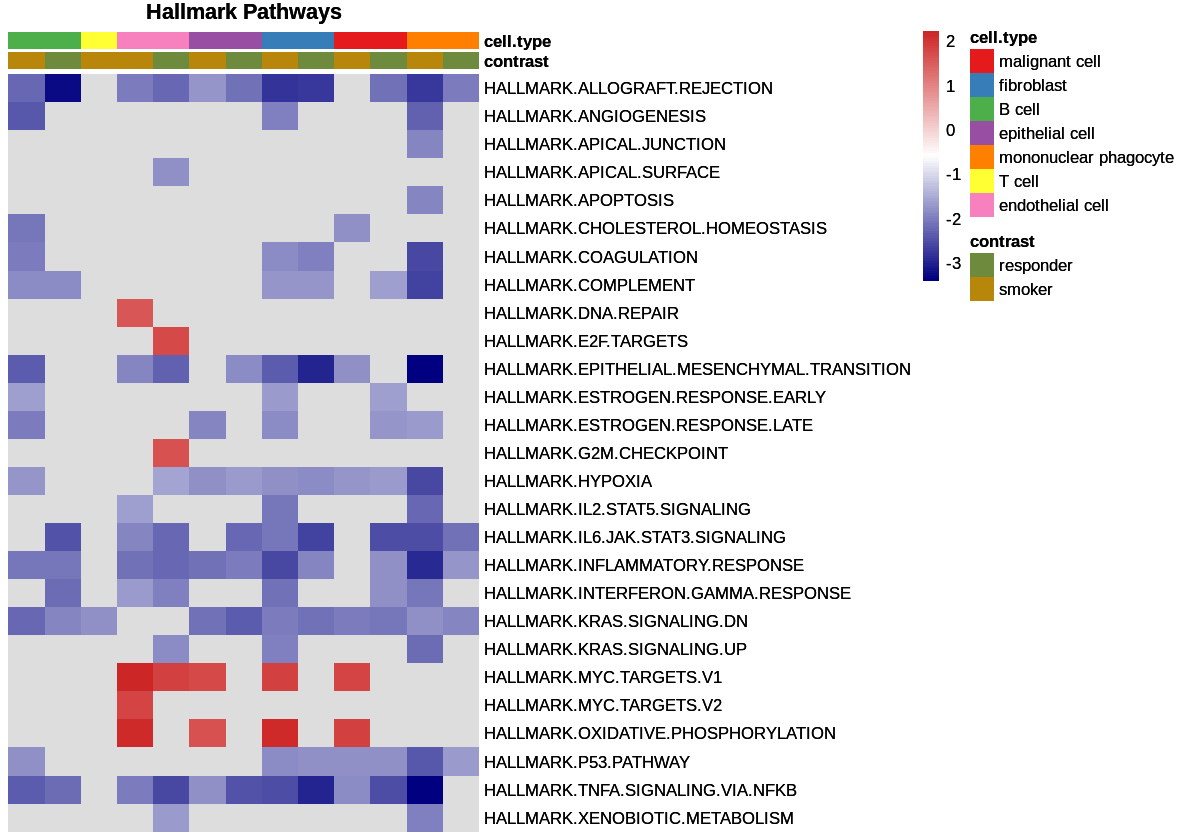

In [8]:
options(repr.plot.width=10,repr.plot.height=7)
save.gs$contrast.celltype <- paste(save.gs$contrast,save.gs$cell.type,sep='.')
save.gs$contrast <- factor(save.gs$contrast,
                           levels = c( 'smoker','responder'))



contrast_colors <- c("responder" = "darkolivegreen4",
                     "smoker" = "darkgoldenrod")
levels <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','plasmacytoid dendritic cell','endothelial cell','mast cell')
master_palette <- setNames(brewer.pal(n = length(levels), "Set1"), levels)
use.palette <- master_palette[!(names(master_palette) %in% c('plasmacytoid dendritic cell', "mast cell"))]
ann_colors = list(contrast = contrast_colors,
                  cell.type = use.palette)  

dat <- prepare.dat.for.heatmap(save.gs, p.crit = 1)

annotation_col <- data.frame(row.names = colnames(dat),
           contrast=stringr::str_split_i(colnames(dat),pattern = '\\.',i=1),
           cell.type= stringr::str_split_i(colnames(dat),pattern = '\\.',i=2))

pheatmap.wrapper(dat, annotation_col, 
                             ann_colors, "Hallmark Pathways", cluster_rows=TRUE,
                             cluster_cols=FALSE,
                             scale="none")

dat <- prepare.dat.for.heatmap(save.gs, p.crit = 0.01)

annotation_col <- data.frame(row.names = colnames(dat),
           contrast=stringr::str_split_i(colnames(dat),pattern = '\\.',i=1),
           cell.type= stringr::str_split_i(colnames(dat),pattern = '\\.',i=2))

pheatmap.wrapper(dat, annotation_col, 
                             ann_colors, "Hallmark Pathways", cluster_rows=FALSE,
                             cluster_cols=FALSE,
                             scale="none")

## Dotplot

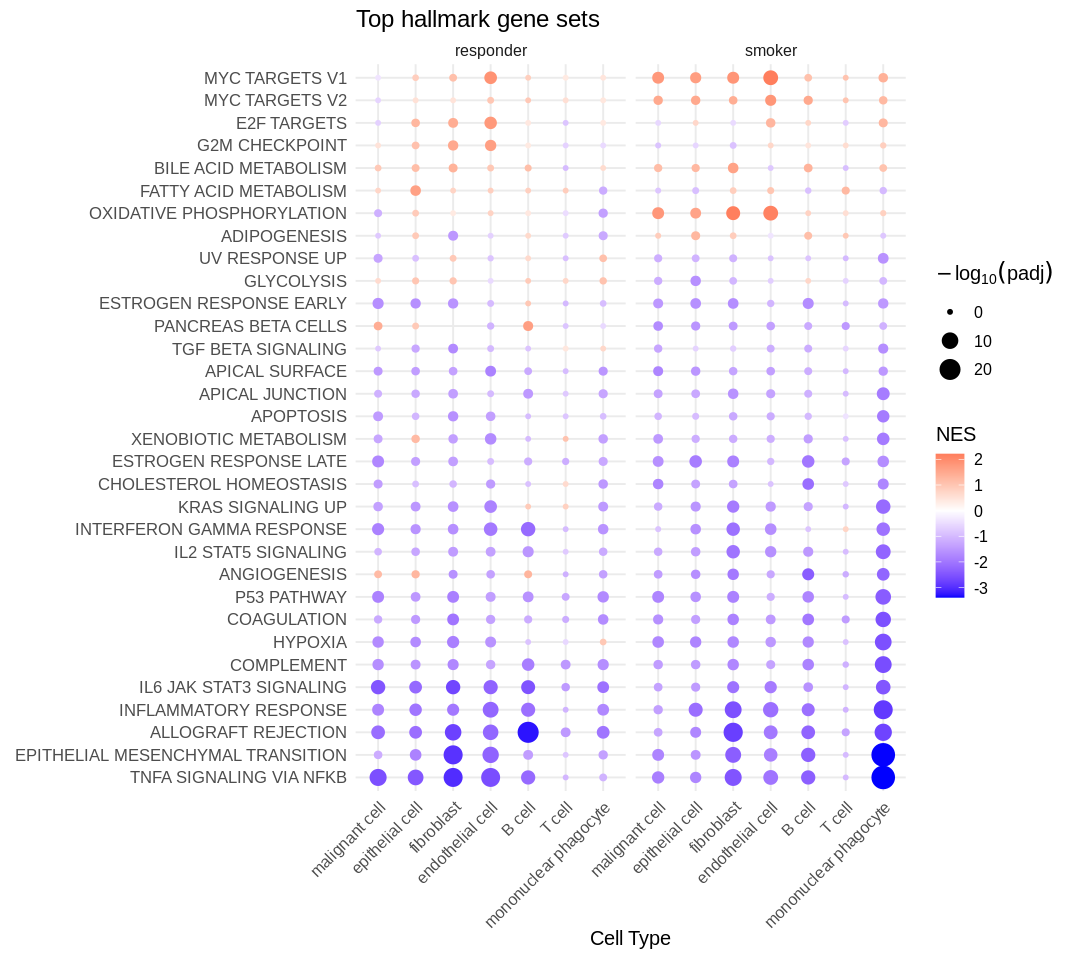

In [135]:
# packages used
options(repr.plot.height=8,repr.plot.width=9)
exc <- 'VACCINATION|INFLUENZA|VACCINE|NEURON|PRETREAT|COVID19|DN|ELECTRON'
# Preprocess the save.gs object
top_pathways <- save.gs %>%
  filter(padj < 0.05) %>%
  filter(NES > 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -NES, n =10) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

bottom_pathways <- save.gs %>%
  filter(padj < 0.05) %>%
  filter(NES < 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = NES, n = 10) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

top_pathways <- unique(c(top_pathways,bottom_pathways))

plot_data <- save.gs %>%
  filter(pathway %in% top_pathways) %>%
  mutate(
    pathway = strip.first.pathway.string(pathway,n=1000),
    pathway = shorten.pathways(pathway,n=100),
    pathway = gsub("_", " ", pathway),
    logpadj = -log10(padj)
  ) 

plot_data$pathway <- factor(plot_data$pathway,
                            levels = unique(plot_data$pathway[order(plot_data$NES)]))

plot_data$contrast <- factor(plot_data$contrast,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = pathway)) +
  geom_point(aes(size = logpadj, color = NES)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](padj)),
    color = "NES",
    title = "Top hallmark gene sets"
  )


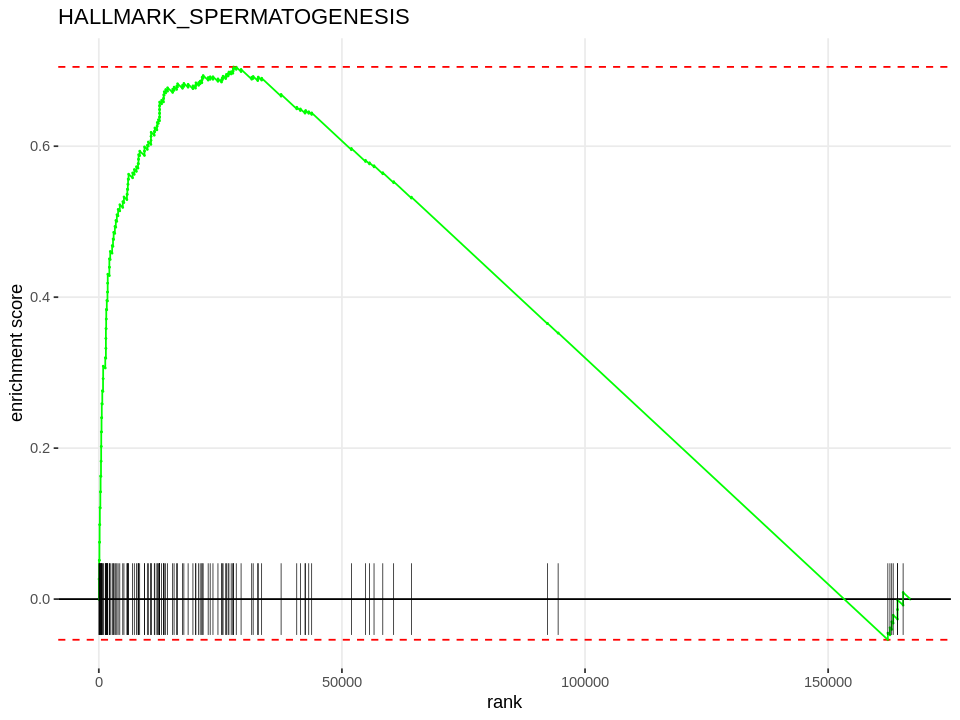

In [24]:
# 1. Create ranked named vector from FindMarkers output
# markers <- de %>% filter 
ranks <- de$avg_log2FC
names(ranks) <- de$Gene
ranks <- sort(ranks, decreasing = TRUE)

# 2. Pick a suspicious pathway from your GSEA results
pathway_to_plot <- "HALLMARK_SPERMATOGENESIS"

# 3. Plot enrichment
fgsea::plotEnrichment(
  pathway = hallmark[[pathway_to_plot]],
  stats = ranks
) + ggtitle(pathway_to_plot)

# C5 gene sets

In [6]:
use.gs <- unique(all.c5$gs_name)#, all.c1$gs_name, all.hallmark$gs_name)
c5 <- list()
for (gs in use.gs){
    c5[[gs]] <- unlist(all.c5[all.c5$gs_name==gs, 'human_gene_symbol'])
}
true_sizes <- vapply(c5, length, integer(1))
print(true_sizes[1:3])


GOBP_10_FORMYLTETRAHYDROFOLATE_METABOLIC_PROCESS 
                                               6 
                    GOBP_2FE_2S_CLUSTER_ASSEMBLY 
                                               6 
           GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS 
                                              18 


In [7]:
save.gs <- data.frame(c())
cell.types <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','endothelial cell') #'plasmacytoid dendritic cell'
tags <- c('response_status.R.vs.NR','any_tobacco_smoker.yes.vs.no')
for (cell in cell.types){
    for (tag in tags){        
        deg <- de %>% filter(cell.type==cell) %>% 
                      filter(contrast ==tag) %>%
                      arrange(-avg_log2FC)
        if (grepl(pattern='response',tag)){
            resp <- 'responder'
        } else {
            resp <- 'smoker'
        }        
        temp <- as.double(deg$avg_log2FC)
        names(temp)<- deg$Gene #This is a named vector
        fgseaRes <- fgsea(pathways = c5, 
                          stats    = temp,
                          minSize  = 15,
                          maxSize  = 500)
        sig.gs <- fgseaRes %>%   
                    # filter(!is.na(log2err)) %>%
                     arrange(padj) #%>%
                     # dplyr::select(-leadingEdge)
        sig.gs$contrast <- resp
        sig.gs$cell.type <- cell
        save.gs <- rbind(save.gs,sig.gs)
    }
}
save.gs$contrast.celltype <- paste(save.gs$contrast,
                                   save.gs$cell.type,
                                   sep='.')
save.gs$contrast <- factor(save.gs$contrast,
                           levels = c( 'smoker','responder'))

Warning message in fgseaMultilevel(...):
“There were 7 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(...):
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning message in fgseaMultilevel(...):
“There were 53 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(...):
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning messa

In [8]:
pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_c5_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx',
                          dim(save.gs)[1]))

print(pnfn)
write.xlsx(save.gs,pnfn)

out <- save.gs %>%  dplyr::left_join(
                            tibble::tibble(pathway = names(true_sizes), total_geneset_size = true_sizes),
                            by = "pathway") %>%
                    mutate(top.genes.observed = lengths(leadingEdge)) %>%
                    mutate(proportion.of.geneset = sprintf('%d/%d',top.genes.observed,total_geneset_size)) %>% 
                    arrange(padj,-lengths(leadingEdge)) %>%
                    dplyr::select(-leadingEdge)

pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_c5_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv',
                          dim(save.gs)[1]))
print(pnfn)
write.csv(out,pnfn)
save.gs <- out

[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_97548_c5_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx"
[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_97548_c5_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv"


## Dot plot

In [16]:
save.gs <- read.csv(file.path(results,'DEG_contrasts_wilcox','pathways',
                                      'GSEA_97548_c5_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv'))
# head(save.gs)

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


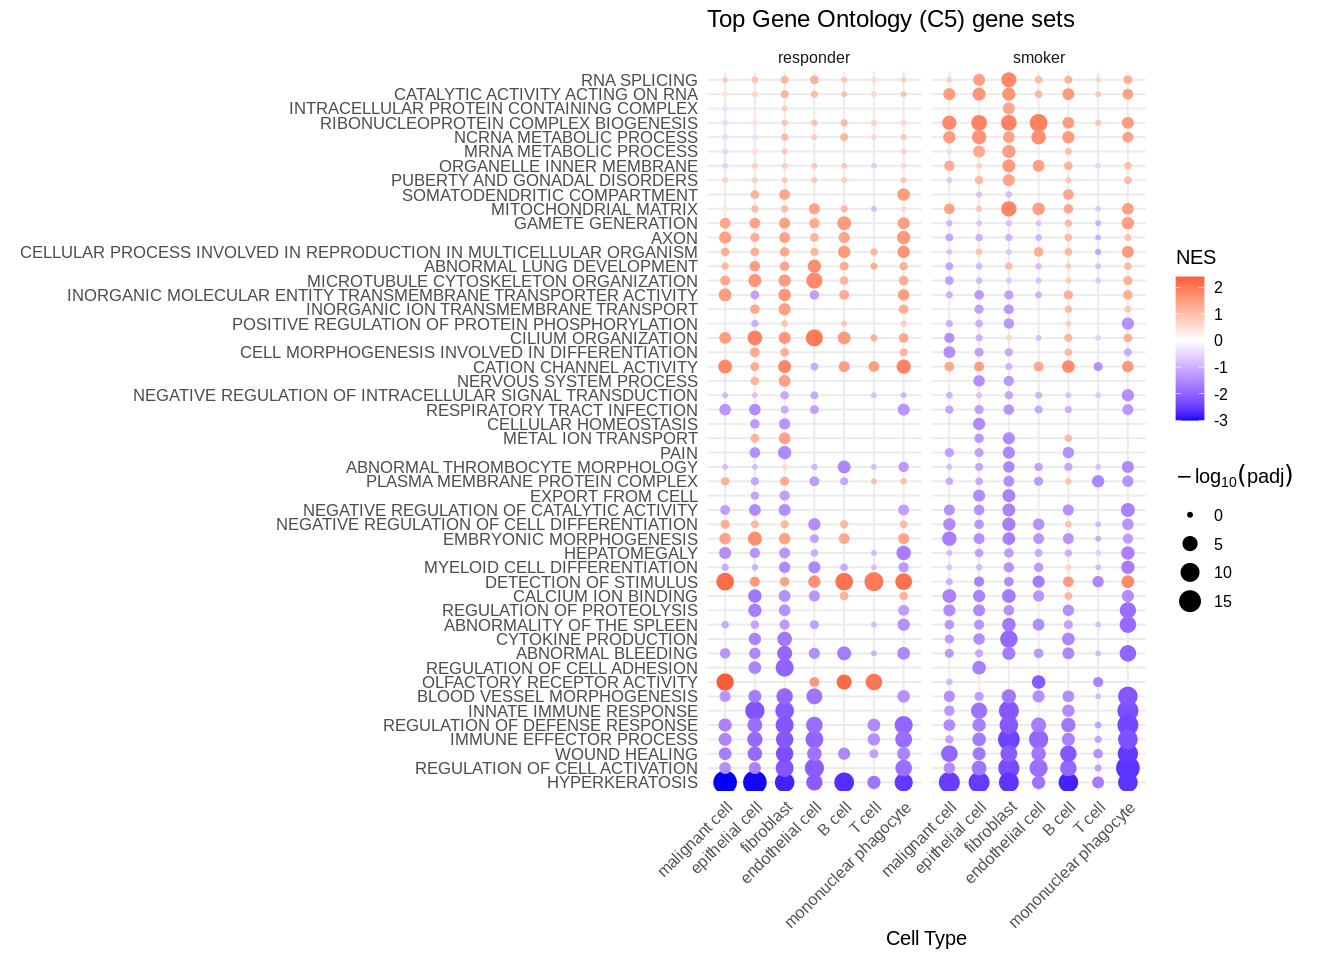

In [10]:
# packages used
options(repr.plot.height=8,repr.plot.width=11)
exc <- 'VACCINATION|INFLUENZA|VACCINE|NEURON|PRETREAT|COVID19|DN|ELECTRON'
# Preprocess the save.gs object
top_pathways <- save.gs %>%
  filter(padj < 0.01) %>%
  filter(NES > 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -NES, n =2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

bottom_pathways <- save.gs %>%
  filter(padj < 0.01) %>%
  filter(NES < 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = NES, n = 2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

top_pathways <- unique(c(top_pathways,bottom_pathways))

plot_data <- save.gs %>%
  filter(pathway %in% top_pathways) %>%
  mutate(
    pathway = strip.first.pathway.string(pathway,n=1000),
    pathway = shorten.pathways(pathway,n=100),
    pathway = gsub("_", " ", pathway),
    logpadj = -log10(padj)
  ) 

plot_data$pathway <- factor(plot_data$pathway,
                            levels = unique(plot_data$pathway[order(plot_data$NES)]))

plot_data$contrast <- factor(plot_data$contrast,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = pathway)) +
  geom_point(aes(size = logpadj, color = NES)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](padj)),
    color = "NES",
    title = "Top Gene Ontology (C5) gene sets"
  )


# C2 genesets

In [102]:
use.gs <- unique(all.c2$gs_name)#, all.c1$gs_name, all.hallmark$gs_name)
c2 <- list()
for (gs in use.gs){
    c2[[gs]] <- unlist(all.c2[all.c2$gs_name==gs, 'human_gene_symbol'])
}
true_sizes <- vapply(c2, length, integer(1))
print(true_sizes[1:3])

ABBUD_LIF_SIGNALING_1_DN ABBUD_LIF_SIGNALING_1_UP ABBUD_LIF_SIGNALING_2_DN 
                      31                       57                        8 


In [103]:
length(true_sizes)

[1] 6366

In [104]:
save.gs <- data.frame(c())
cell.types <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','endothelial cell') #'plasmacytoid dendritic cell'
tags <- c('response_status.R.vs.NR','any_tobacco_smoker.yes.vs.no')
for (cell in cell.types){
    for (tag in tags){        
        deg <- de %>% filter(cell.type==cell) %>% 
                      filter(contrast ==tag) %>%
                      arrange(-avg_log2FC)
        if (grepl(pattern='response',tag)){
            resp <- 'responder'
        } else {
            resp <- 'smoker'
        }        
        temp <- as.double(deg$avg_log2FC)
        names(temp)<- deg$Gene #This is a named vector
        fgseaRes <- fgsea(pathways = c2, 
                          stats    = temp,
                          minSize  = 15,
                          maxSize  = 500)
        sig.gs <- fgseaRes %>%   
                    # filter(!is.na(log2err)) %>%
                     arrange(padj) #%>%
                     # dplyr::select(-leadingEdge)
        sig.gs$contrast <- resp
        sig.gs$cell.type <- cell
        save.gs <- rbind(save.gs,sig.gs)
    }
}
save.gs$contrast.celltype <- paste(save.gs$contrast,
                                   save.gs$cell.type,
                                   sep='.')
save.gs$contrast <- factor(save.gs$contrast,
                           levels = c( 'smoker','responder'))

Warning message in fgseaMultilevel(...):
“There were 5 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(...):
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning message in fgseaMultilevel(...):
“There were 45 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(...):
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning messa

In [105]:
pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_C2_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx',
                          dim(save.gs)[1]))

print(pnfn)
write.xlsx(save.gs,pnfn)

out <- save.gs %>%  dplyr::left_join(
                            tibble::tibble(pathway = names(true_sizes), total_geneset_size = true_sizes),
                            by = "pathway") %>%
                    mutate(top.genes.observed = lengths(leadingEdge)) %>%
                    mutate(proportion.of.geneset = sprintf('%d/%d',top.genes.observed,total_geneset_size)) %>% 
                    arrange(padj,-lengths(leadingEdge)) %>%
                    dplyr::select(-leadingEdge)

pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_C2_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv',
                          dim(save.gs)[1]))
print(pnfn)
write.csv(out,pnfn)
save.gs <- out

[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_57368_C2_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx"
[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_57368_C2_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv"


## Dot plot

In [11]:
save.gs <- read.csv(file.path(results,'DEG_contrasts_wilcox','pathways',
                                      'GSEA_57368_C2_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv'))
# head(save.gs)

Warning message:
“Removed 18 rows containing missing values or values outside the scale range
(`geom_point()`).”


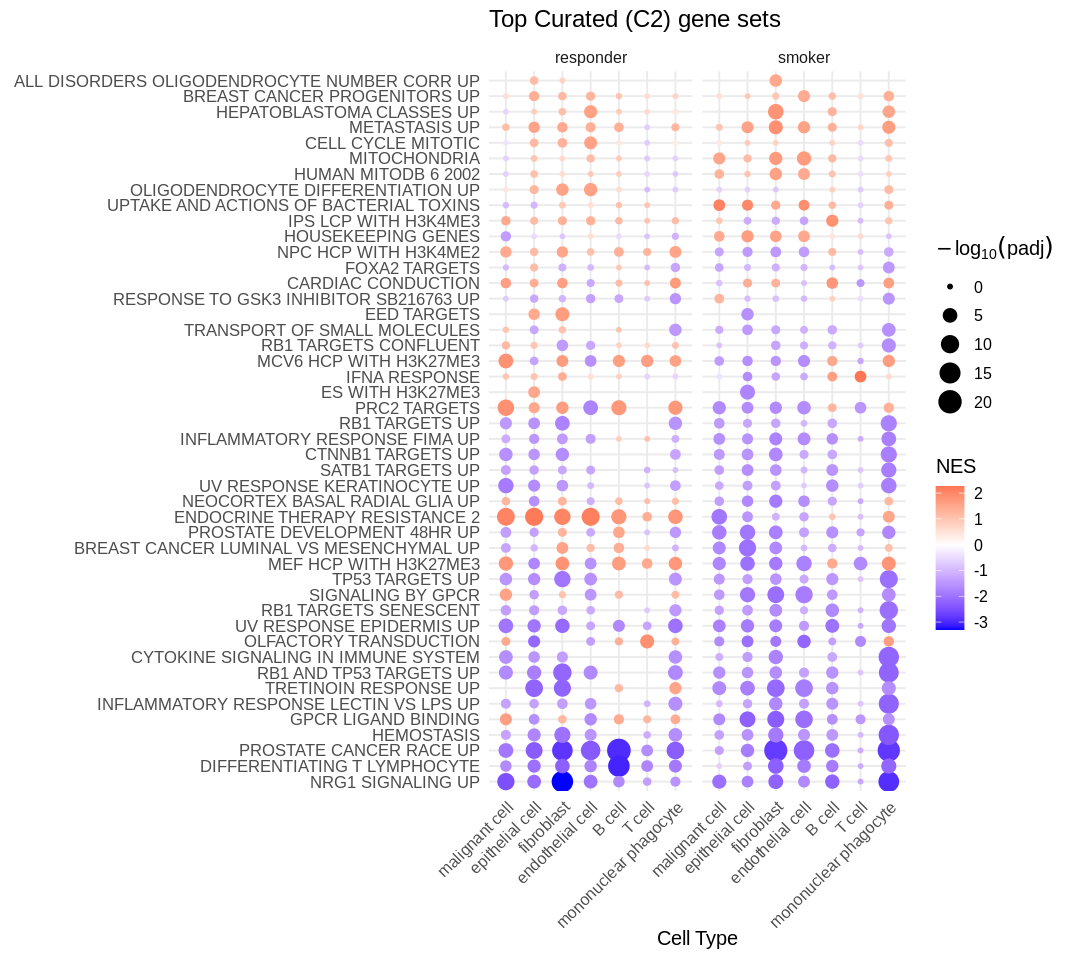

In [12]:
# packages used
options(repr.plot.height=8,repr.plot.width=9)
exc <- 'VACCINATION|INFLUENZA|VACCINE|NEURON|PRETREAT|COVID19|DN|ELECTRON'
# Preprocess the save.gs object
top_pathways <- save.gs %>%
  filter(padj < 0.01) %>%
  filter(NES > 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -NES, n =2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

bottom_pathways <- save.gs %>%
  filter(padj < 0.01) %>%
  filter(NES < 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = NES, n = 2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

top_pathways <- unique(c(top_pathways,bottom_pathways))

plot_data <- save.gs %>%
  filter(pathway %in% top_pathways) %>%
  mutate(
    pathway = strip.first.pathway.string(pathway,n=1000),
    pathway = shorten.pathways(pathway,n=100),
    pathway = gsub("_", " ", pathway),
    logpadj = -log10(padj)
  ) 

plot_data$pathway <- factor(plot_data$pathway,
                            levels = unique(plot_data$pathway[order(plot_data$NES)]))

plot_data$contrast <- factor(plot_data$contrast,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = pathway)) +
  geom_point(aes(size = logpadj, color = NES)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](padj)),
    color = "NES",
    title = "Top Curated (C2) gene sets"
  )


# C7 genesets

In [ ]:
use.gs <- unique(all.c7$gs_name)#, all.c1$gs_name, all.hallmark$gs_name)
c7 <- list()
for (gs in use.gs){
    c7[[gs]] <- unlist(all.c7[all.c7$gs_name==gs, 'human_gene_symbol'])
}
true_sizes <- vapply(c7, length, integer(1))
print(true_sizes[1:2])

In [64]:
length(true_sizes)

[1] 5219

In [ ]:
save.gs <- data.frame(c())
cell.types <- c('malignant cell','fibroblast','B cell','epithelial cell','mononuclear phagocyte',
            'T cell','endothelial cell') #'plasmacytoid dendritic cell'
tags <- c('response_status.R.vs.NR','any_tobacco_smoker.yes.vs.no')
for (cell in cell.types){
    for (tag in tags){        
        deg <- de %>% filter(cell.type==cell) %>% 
                      filter(contrast ==tag) %>%
                      arrange(-avg_log2FC)
        if (grepl(pattern='response',tag)){
            resp <- 'responder'
        } else {
            resp <- 'smoker'
        }        
        temp <- as.double(deg$avg_log2FC)
        names(temp)<- deg$Gene #This is a named vector
        fgseaRes <- fgsea(pathways = c7, 
                          stats    = temp,
                          minSize  = 15,
                          maxSize  = 500)
        sig.gs <- fgseaRes %>%   
                    # filter(!is.na(log2err)) %>%
                     arrange(padj) #%>%
                     # dplyr::select(-leadingEdge)
        sig.gs$contrast <- resp
        sig.gs$cell.type <- cell
        save.gs <- rbind(save.gs,sig.gs)
    }
}
save.gs$contrast.celltype <- paste(save.gs$contrast,
                                   save.gs$cell.type,
                                   sep='.')
save.gs$contrast <- factor(save.gs$contrast,
                           levels = c( 'smoker','responder'))

In [66]:
pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_C7_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx',
                          dim(save.gs)[1]))

print(pnfn)
write.xlsx(save.gs,pnfn)

out <- save.gs %>%  dplyr::left_join(
                            tibble::tibble(pathway = names(true_sizes), total_geneset_size = true_sizes),
                            by = "pathway") %>%
                    mutate(top.genes.observed = lengths(leadingEdge)) %>%
                    mutate(proportion.of.geneset = sprintf('%d/%d',top.genes.observed,total_geneset_size)) %>% 
                    arrange(padj,-lengths(leadingEdge)) %>%
                    dplyr::select(-leadingEdge)

pnfn <- file.path(results,'DEG_contrasts_wilcox','pathways',
                  sprintf('GSEA_%d_C7_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv',
                          dim(save.gs)[1]))
print(pnfn)
write.csv(out,pnfn)
save.gs <- out

[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_70820_C7_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx"
[1] "/ix/rbao/Projects/HCC-CBS-228-Hillman-DDressman-CURE-Visium-scRNASeq/results/visium/DEG_contrasts_wilcox/pathways/GSEA_70820_C7_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv"


In [50]:
full <- read.xlsx(file.path(results,'DEG_contrasts_wilcox','pathways',
                            'GSEA_70820_C7_unfiltered_pathways_by_contrast_and_celltype_with_genes.xlsx'))
full <- full %>%
  dplyr::mutate(leadingEdge = strsplit(leadingEdge, ","))

## Dot plot

In [14]:
save.gs <- read.csv(file.path(results,'DEG_contrasts_wilcox','pathways',
                                      'GSEA_70820_C7_unfiltered_pathways_by_contrast_and_celltype_drop_genes.csv'))
# head(save.gs)

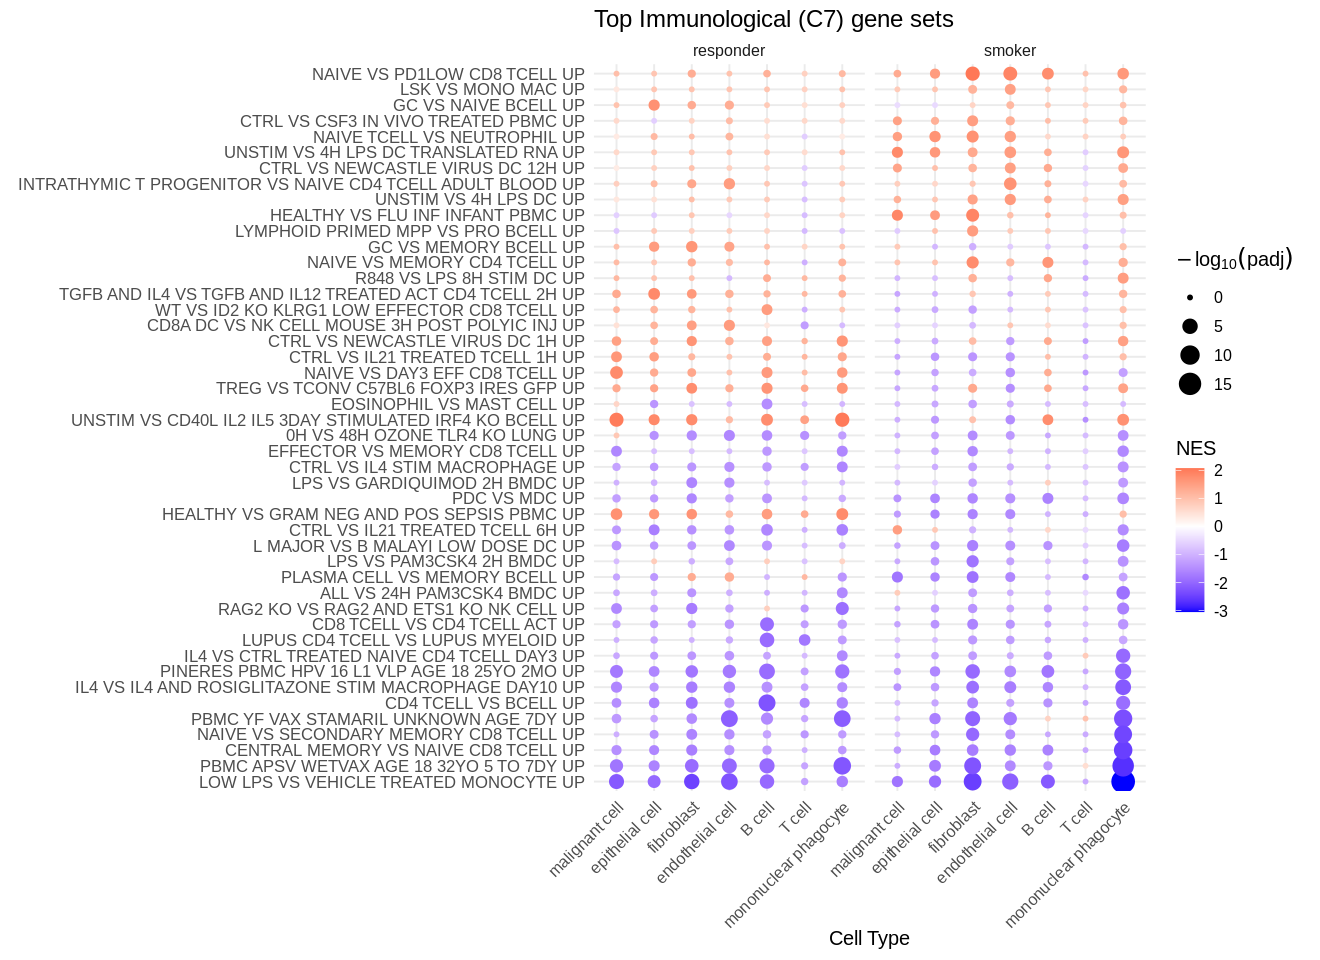

In [15]:
# packages used
options(repr.plot.height=8,repr.plot.width=11)
# ggplot2 v3.5.1, dplyr v1.1.4, scales v1.3.0, forcats v1.0.0

library(ggplot2)
library(dplyr)
exc <- 'VACCINATION|INFLUENZA|VACCINE|NEURON|PRETREAT|COVID19|DN|FLUARIX'
# Preprocess the save.gs object
top_pathways <- save.gs %>%
  filter(padj < 0.05) %>%
  filter(NES > 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = -NES, n =2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

bottom_pathways <- save.gs %>%
  filter(padj < 0.05) %>%
  filter(NES < 0) %>%
  filter(!grepl(pattern = exc,pathway)) %>%
  group_by(cell.type, contrast) %>%
  slice_max(order_by = NES, n = 2) %>%
  ungroup() %>%
  distinct(pathway) %>%
  pull(pathway)

top_pathways <- unique(c(top_pathways,bottom_pathways))

plot_data <- save.gs %>%
  filter(pathway %in% top_pathways) %>%
  mutate(
    pathway = strip.first.pathway.string(pathway,n=1000),
    pathway = shorten.pathways(pathway,n=100),
    pathway = gsub("_", " ", pathway),
    logpadj = -log10(padj)
  ) 

plot_data$pathway <- factor(plot_data$pathway,
                            levels = unique(plot_data$pathway[order(plot_data$NES)]))

plot_data$contrast <- factor(plot_data$contrast,
                           levels = c('responder', 'smoker'))
plot_data$cell.type <- factor(plot_data$cell.type,
                              levels = cell.types <- c('malignant cell','epithelial cell','fibroblast',
                                                       'endothelial cell',
                                                       'B cell','T cell',
                                                       'mononuclear phagocyte'))
            # ,) #'plasmacytoid dendritic cell'
# Plot: pathways on Y, cell.type on X, dot shows NES & padj
ggplot(plot_data, aes(x = cell.type, y = pathway)) +
  geom_point(aes(size = logpadj, color = NES)) +
  facet_wrap(~ contrast) +
  scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  scale_size_continuous(range = c(1, 6)) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  labs(
    x = "Cell Type",
    y = NULL,
    size = expression(-log[10](padj)),
    color = "NES",
    title = "Top Immunological (C7) gene sets"
  )
